In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from src import soporte_correlacion as sp_corr

In [2]:
pd.set_option("display.max_columns",None) #display todas las columnas
df_hr = pd.read_csv("hr_final.csv",index_col=0)

df_hr.head()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,single,8,yes,11,3,1,0,8,0,1,6,4,0,5.0,41,4,5993.0
1,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,married,1,no,23,4,4,1,10,3,3,10,7,1,7.0,49,2,5130.0
2,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,single,6,yes,15,3,2,0,7,3,3,0,0,0,0.0,37,3,2090.0
3,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,married,1,yes,11,3,3,0,8,3,3,8,7,3,0.0,33,3,2909.0
4,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,married,9,no,12,3,4,1,6,3,3,2,2,2,2.0,27,2,3468.0


In [3]:
df_hr.columns

Index(['attrition', 'business_travel', 'department', 'distance_from_home',
       'education', 'education_field', 'employee_number',
       'environment_satisfaction', 'gender', 'job_involvement', 'job_level',
       'job_role', 'marital_status', 'num_companies_worked', 'over_time',
       'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager', 'age',
       'job_satisfaction', 'monthly_income'],
      dtype='str')

### **<font color="red">¿Existe una brecha salarial entre los empleados que se quedan y los que se van?</font>**
      - Herramienta: sns.boxplot(x='attrition', y='monthly_income', data=df)

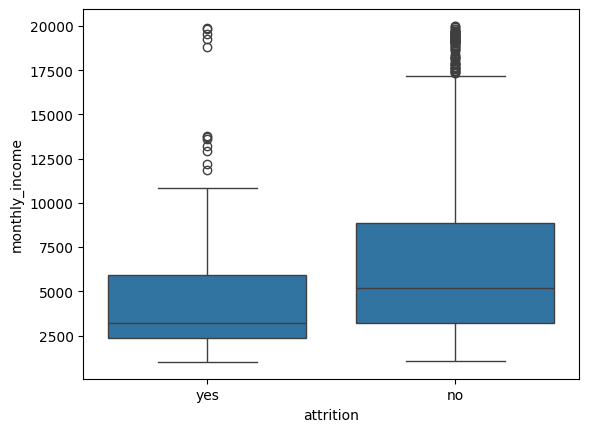

In [4]:
sns.boxplot(data=df_hr,x="attrition", y="monthly_income");

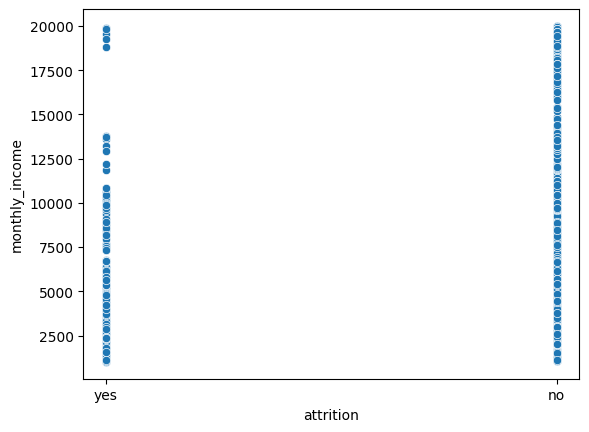

In [5]:
sns.scatterplot(data=df_hr,x="attrition", y="monthly_income");

### **<font color="red">¿El trabajo extra (Overtime) es un detonante para la rotación? </font>**
       - Herramienta: sns.countplot(x='over_time', hue='attrition', data=df)

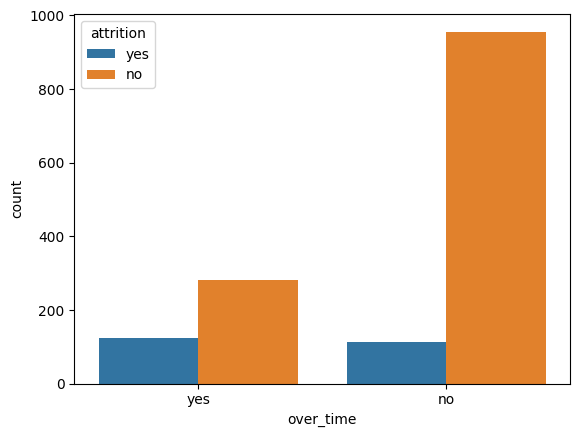

In [6]:
sns.countplot(x='over_time', hue='attrition', data=df_hr);



### **<font color="red">¿Influye la distancia al hogar en la decisión de abandonar la empresa? </font>**
       - Herramienta: sns.kdeplot comparando distance_from_home para ambos grupos de attrition.

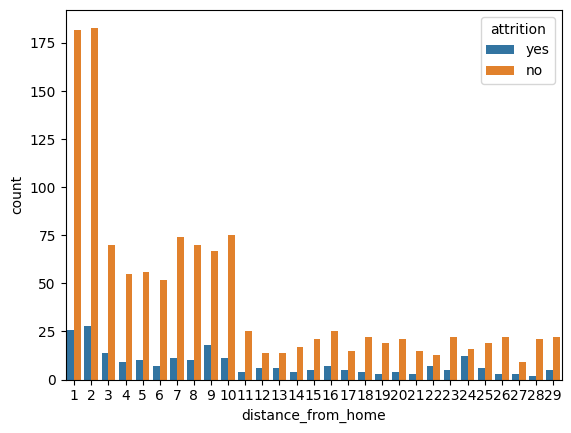

In [7]:
sns.countplot(data=df_hr, x="distance_from_home", hue="attrition");
#dibuja la estimación de densidad kernel de `distance_from_home` para cada valor de `attrition`, comparando la distribución de distancias entre los que se quedan y los que se van.

### **<font color="red"> ¿Qué departamentos o roles tienen la tasa de rotación más alta?</font>**
    - Herramienta: Gráfico de barras apiladas o sns.countplot con job_role o department.

<Axes: xlabel='attrition', ylabel='count'>

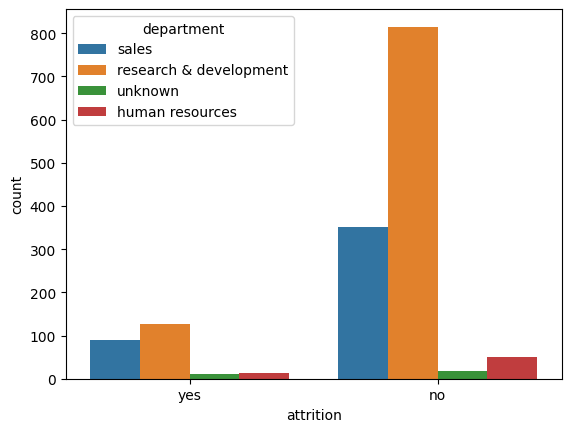

In [8]:
sns.countplot(data=df_hr, x="attrition", hue="department")

<Axes: xlabel='attrition', ylabel='count'>

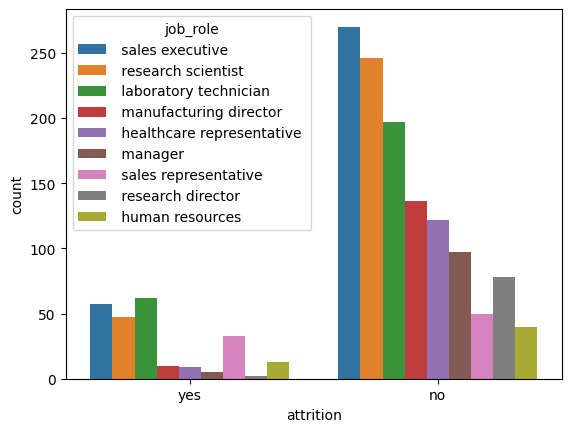

In [9]:
sns.countplot(data=df_hr, x="attrition", hue="job_role")

# 2. Análisis de Satisfacción y Clima
  Se centra en las métricas de bienestar (job_satisfaction, environment_satisfaction, work_life_balance).

### **<font color="red"> ¿Cómo se distribuye la satisfacción laboral según el nivel del puesto (job_level)?</font>**
       * Herramienta: sns.violinplot(x='job_level', y='job_satisfaction', data=df)

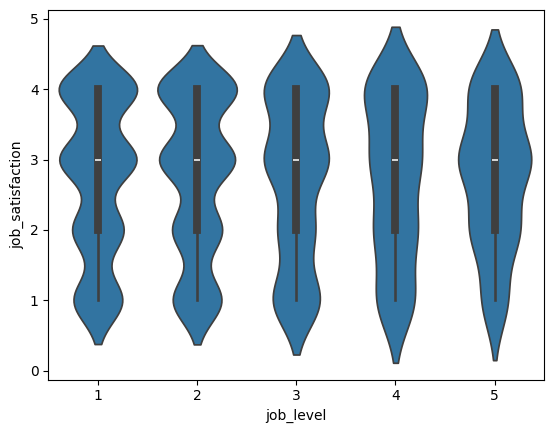

In [10]:
sns.violinplot(data=df_hr,x="job_level",y="job_satisfaction");

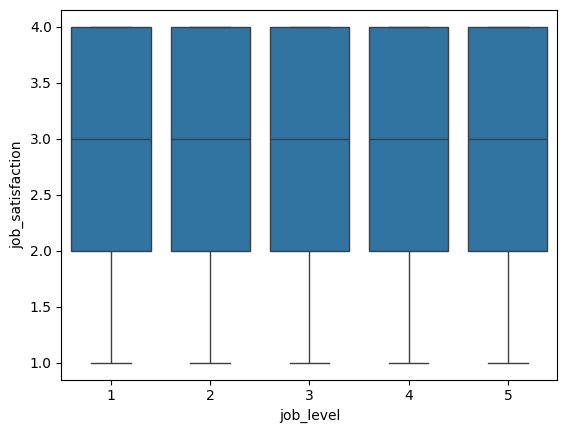

In [11]:
sns.boxplot(data=df_hr,x="job_level",y="job_satisfaction");

**Yo aqui haría un groupby por job level de la media de satisfaction, para aclarar los datos**

### **<font color="red"> ¿Existe relación entre el equilibrio vida-trabajo y la satisfacción en el entorno?</font>**
    - Herramienta: Matriz de contingencia (Heatmap) entre work_life_balance y environment_satisfaction.

In [12]:
tablaconting1 = pd.crosstab(df_hr["work_life_balance"], df_hr["environment_satisfaction"], normalize="index")*100;  #todas las filas suma el 100%, por ej. un 25% no está contento, por otro lado un 31% 4/4
tablaconting1.style.background_gradient(cmap='Blues')


environment_satisfaction,1,2,3,4
work_life_balance,,,,
1,25.000000,16.250000,27.500000,31.250000
2,19.476744,22.674419,29.069767,28.779070
3,18.617614,19.175028,30.992196,31.215162
4,19.607843,16.339869,34.640523,29.411765


In [13]:
tablaconting2 = pd.crosstab(df_hr["work_life_balance"], df_hr["environment_satisfaction"], normalize="columns")*100;  #todas las columnas suma el 100%, por ejemplo, el 58· odia su entorno con equilibrio al 3.
tablaconting2.style.background_gradient(cmap='Blues')

environment_satisfaction,1,2,3,4
work_life_balance,,,,
1,7.042254,4.513889,4.856512,5.567929
2,23.591549,27.083333,22.075055,22.048998
3,58.802817,59.722222,61.368653,62.360802
4,10.563380,8.680556,11.699779,10.022272


<Axes: xlabel='environment_satisfaction', ylabel='work_life_balance'>

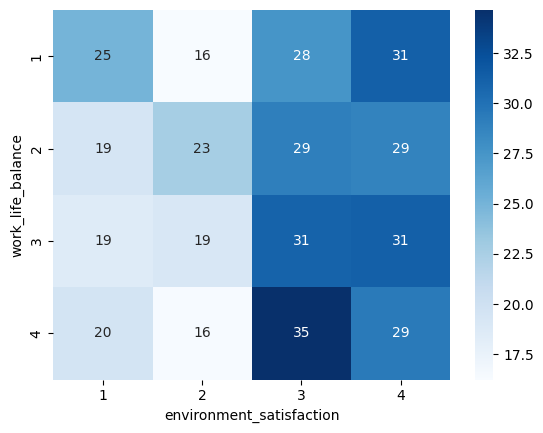

In [14]:
sns.heatmap(tablaconting1, annot=True, cmap="Blues", cbar=True)


<Axes: xlabel='environment_satisfaction', ylabel='work_life_balance'>

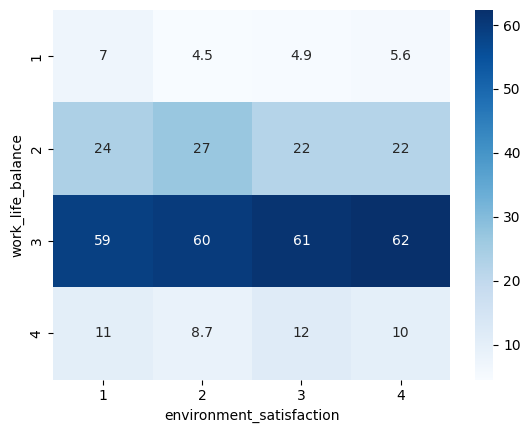

In [15]:
sns.heatmap(tablaconting2, annot=True, cmap="Blues", cbar=True)

### **<font color="red"> ¿Los empleados con más años bajo el mismo manager tienen mayor satisfacción?</float>**
    - Herramienta: sns.lineplot o sns.barplot comparando years_with_curr_manager con job_satisfaction.

<Axes: xlabel='years_with_curr_manager', ylabel='job_satisfaction'>

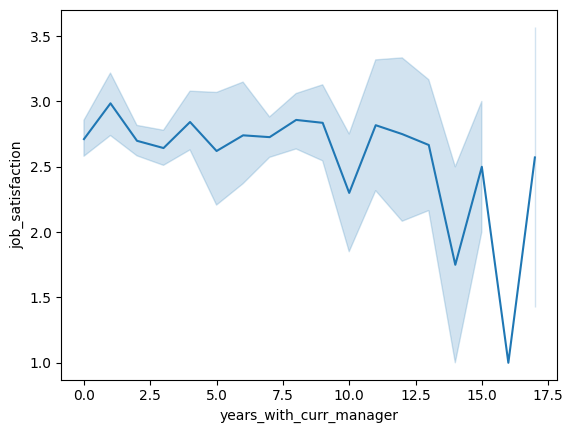

In [16]:
sns.lineplot(data=df_hr,x="years_with_curr_manager",y="job_satisfaction")

<Axes: xlabel='years_with_curr_manager', ylabel='job_satisfaction'>

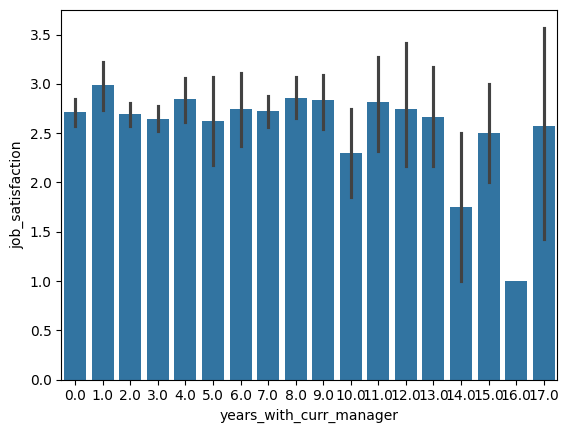

In [17]:
sns.barplot(data=df_hr,x="years_with_curr_manager",y="job_satisfaction")

# 3. Correlaciones y Factores Numéricos
  Para identificar qué variables se mueven juntas.

### **<font color="red"> ¿Cuáles son las variables numéricas que más influyen en el ingreso mensual?</font>**
       - Herramienta: Mapa de calor de correlaciones (sns.heatmap(df.corr())) filtrando por monthly_income.

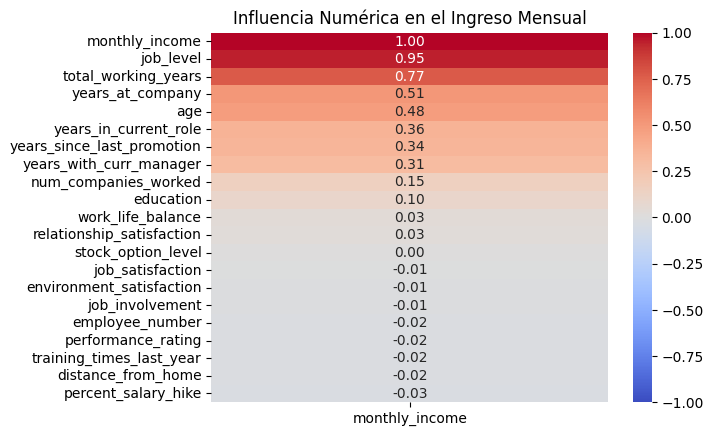

In [18]:
# Calculamos la matriz de correlación completa (solo numéricas)
corr_matrix = df_hr.corr(numeric_only=True)

# Usamos sort_values para poner las correlaciones más altas arriba
income_corr = corr_matrix[['monthly_income']].sort_values(by='monthly_income', ascending=False)

# 3. Graficamos el Heatmap enfocado
sns.heatmap( income_corr,annot=True,cmap='coolwarm',vmin=-1, vmax=1,fmt=".2f")
# Escala de color: azul (negativo), blanco (cero), rojo (positivo)
# Fija la escala de color de -1 a 1
# Formato de dos decimales

plt.title("Influencia Numérica en el Ingreso Mensual", fontsize=12)
plt.show()

### **<font color="red"> ¿Existe una correlación entre el porcentaje de aumento salarial (percent_salary_hike) y el desempeño (performance_rating)?</font>**
       * Herramienta: sns.scatterplot con regresión.

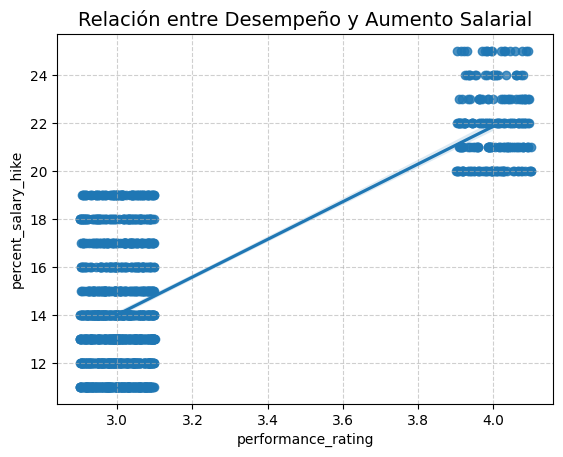

In [19]:

# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.regplot(data=df_hr,x="performance_rating",y="percent_salary_hike",x_jitter=0.1) # x_jitter Separa un poco los puntos para ver densidad

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

### **<font color="red"> ¿Cómo afecta la edad y los años de experiencia al nivel de ingresos?</font>**
    - Herramienta: sns.jointplot para ver la distribución y la relación entre age y total_working_years.

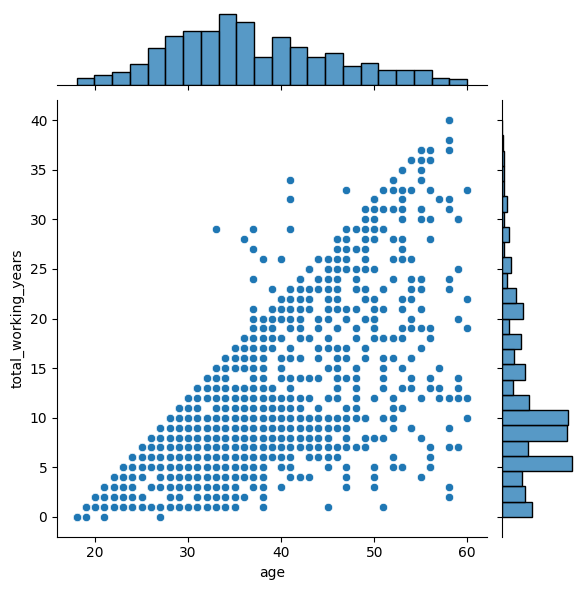

In [20]:
sns.jointplot(data=df_hr, x="age",y="total_working_years");

#Histograma de arriba (Edad): Te dice que la mayoría de tus empleados tienen entre 30 y 40 años (donde está el pico más alto). Tienes muy pocos empleados menores de 20 o mayores de 55.
#Histograma de la derecha (Experiencia): Te muestra que hay muchísima gente concentrada en el rango de 5 a 10 años de experiencia.
#¡OJO con los datos erróneos!

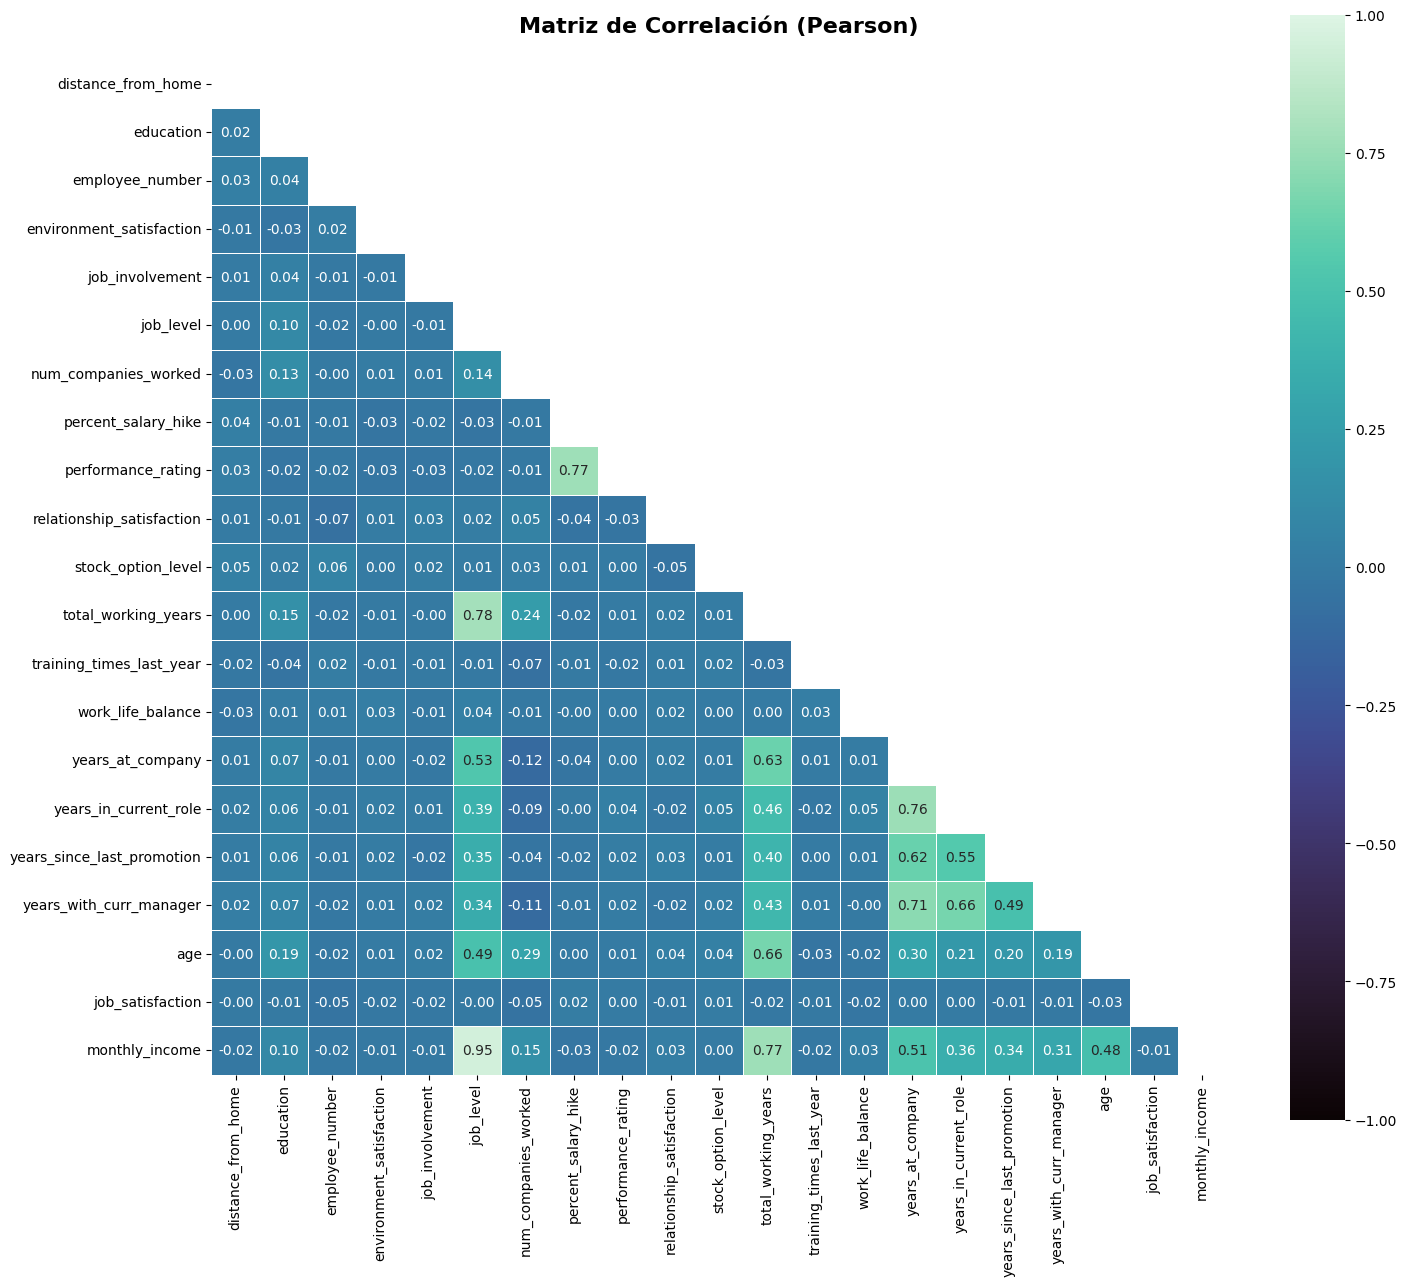

,distance_from_home,education,employee_number,environment_satisfaction,job_involvement,job_level,num_companies_worked,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
distance_from_home,1.000000,0.018657,0.033661,-0.014698,0.006508,0.004109,-0.029712,0.038188,0.026710,0.006449,0.045773,0.002856,-0.023303,-0.026235,0.008578,0.017595,0.009423,0.023674,-0.002929,-0.003022,-0.019298
education,0.018657,1.000000,0.041203,-0.029204,0.044284,0.102684,0.127229,-0.008856,-0.023749,-0.009512,0.017174,0.149987,-0.040722,0.009210,0.070422,0.061863,0.055175,0.069245,0.193027,-0.007398,0.098058
employee_number,0.033661,0.041203,1.000000,0.018730,-0.010504,-0.020093,-0.001429,-0.012928,-0.020034,-0.069392,0.060268,-0.016833,0.020226,0.010066,-0.010669,-0.007557,-0.008669,-0.015853,-0.016915,-0.045984,-0.015931
environment_satisfaction,-0.014698,-0.029204,0.018730,1.000000,-0.008620,-0.000025,0.010761,-0.033054,-0.030318,0.008896,0.003890,-0.005698,-0.010574,0.028233,0.000468,0.017023,0.015344,0.005146,0.007409,-0.018462,-0.008153
job_involvement,0.006508,0.044284,-0.010504,-0.008620,1.000000,-0.010865,0.014902,-0.016304,-0.029004,0.034427,0.022569,-0.004026,-0.005283,-0.014542,-0.020585,0.009543,-0.023694,0.018521,0.019128,-0.020086,-0.012508
job_level,0.004109,0.102684,-0.020093,-0.000025,-0.010865,1.000000,0.142669,-0.033623,-0.021138,0.021539,0.013924,0.782120,-0.011790,0.037738,0.534136,0.388937,0.353626,0.339034,0.494986,-0.001666,0.950467
num_companies_worked,-0.029712,0.127229,-0.001429,0.010761,0.014902,0.142669,1.000000,-0.009811,-0.013298,0.051499,0.029898,0.238126,-0.069894,-0.008980,-0.117144,-0.089508,-0.035894,-0.106016,0.293893,-0.050520,0.149956
percent_salary_hike,0.038188,-0.008856,-0.012928,-0.033054,-0.016304,-0.033623,-0.009811,1.000000,0.772752,-0.040130,0.005815,-0.018648,-0.006451,-0.003516,-0.035268,-0.000546,-0.021718,-0.012917,0.004642,0.016118,-0.025658
performance_rating,0.026710,-0.023749,-0.020034,-0.030318,-0.029004,-0.021138,-0.013298,0.772752,1.000000,-0.031901,0.003223,0.007029,-0.023307,0.002180,0.004235,0.035811,0.018490,0.015242,0.006732,0.002669,-0.016967
relationship_satisfaction,0.006449,-0.009512,-0.069392,0.008896,0.034427,0.021539,0.051499,-0.040130,-0.031901,1.000000,-0.046292,0.023379,0.008511,0.020047,0.018635,-0.015681,0.032851,-0.018356,0.036322,-0.010761,0.025886


In [21]:
sp_corr.matriz_correlacion_visual(df_hr)